# Replicación: QSVM — Clasificación
## Basado en Suzuki et al. 2023 (arXiv:2307.02091)

**Experimentos de clasificación (QSVC):**
- Credit Card Fraud Detection
- MNIST (dígito 0 vs 1)
- Fashion-MNIST (T-shirt vs Trouser)

Comparación entre SVM clásico (kernel RBF) y QSVC (kernel cuántico de fidelidad, simulación noiseless).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import os
import json
import gzip
import struct
from pathlib import Path
from sklearn.svm import SVC, SVR
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, r2_score, mean_squared_error,
    roc_curve, auc as sklearn_auc, ConfusionMatrixDisplay, balanced_accuracy_score
)

try:
    from qiskit import QuantumCircuit
    from qiskit.circuit import ParameterVector
    from qiskit.quantum_info import Statevector
    QISKIT_AVAILABLE = True
    print("[OK] Qiskit disponible")
except ImportError:
    QISKIT_AVAILABLE = False
    print("[WARNING] Qiskit no disponible — solo experimentos clasicos")

OUTPUT_DIR = 'resultados_experimentos'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/figuras', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'clasico': '#1976D2', 'cuantico': '#388E3C', 'paper_hw': '#F57C00'}
RANDOM_STATE = 42

print(f"[OK] Directorio de salida: {OUTPUT_DIR}/")


[OK] Qiskit disponible
[OK] Directorio de salida: resultados_experimentos/


---
## Funciones del Kernel Cuántico

Implementación del circuito superficial de la Ec. (1) del paper.

In [2]:
def make_paper_feature_map(n_qubits, lam=1.0):
    """
    Circuito cuantico superficial — Ec. 1 de Suzuki et al. 2023

    |phi(x)> = (tensor Rz(lam*xq)) U_ent (tensor Ry(lam*xq)Rz(lam*xq)H) |0^n>

    Leido de derecha a izquierda:
      1. Hadamard en cada qubit
      2. Rz(lam*xq) y Ry(lam*xq) en cada qubit
      3. Cadena de CNOTs (entrelazamiento)
      4. Rz(lam*xq) en cada qubit
    """
    x = ParameterVector('x', n_qubits)
    qc = QuantumCircuit(n_qubits)
    for q in range(n_qubits):
        qc.h(q)
        qc.rz(lam * x[q], q)
        qc.ry(lam * x[q], q)
    for q in range(n_qubits - 1):
        qc.cx(q, q + 1)
    for q in range(n_qubits):
        qc.rz(lam * x[q], q)
    return qc


def get_statevectors(X, feature_map):
    """Calcula vectores de estado para cada punto de datos."""
    svs = []
    for x in X:
        bound = feature_map.assign_parameters(x)
        sv = Statevector(bound).data
        svs.append(sv)
    return svs


def compute_kernel_matrix(svs_a, svs_b=None):
    """K[i,j] = |<phi(xi)|phi(xj)>|^2  (kernel cuantico de fidelidad)"""
    if svs_b is None:
        svs_b = svs_a
    K = np.zeros((len(svs_a), len(svs_b)))
    for i, sva in enumerate(svs_a):
        for j, svb in enumerate(svs_b):
            K[i, j] = abs(np.dot(sva.conj(), svb)) ** 2
    return K


def kernel_alignment(K1, K2):
    """
    Alineamiento de Frobenius A(K1, K2) — Ec. 7 del paper.
    Mide la similitud entre dos matrices kernel como el coseno
    del angulo entre ellas vistas como vectores.
    """
    frob = lambda A, B: np.sum(A * B)
    denom = np.sqrt(frob(K1, K1) * frob(K2, K2))
    return frob(K1, K2) / denom if denom > 0 else 0.0


def low_rank_approx(K, r):
    """Aproximacion de bajo rango via eigendescomposicion (Sec. 4.2 del paper)"""
    eigenvalues, eigenvectors = np.linalg.eigh(K)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    K_lr = sum(eigenvalues[k] * np.outer(eigenvectors[:, k], eigenvectors[:, k])
               for k in range(r))
    return K_lr, eigenvalues, eigenvectors


def classical_rbf_kernel(X_a, X_b, gamma=1.0):
    """Kernel gaussiano clasico K(x,x') = exp(-gamma * ||x-x'||^2)"""
    from sklearn.metrics.pairwise import rbf_kernel
    return rbf_kernel(X_a, X_b, gamma=gamma)


print("[OK] Funciones del kernel cuantico definidas")
print(f"Rango del kernel K(x,x) = 1 (diagonal siempre = 1 por definicion)")


[OK] Funciones del kernel cuantico definidas
Rango del kernel K(x,x) = 1 (diagonal siempre = 1 por definicion)


In [3]:
# ─── Metricas ─────────────────────────────────────────────────────────────────

def classification_metrics(y_true, y_pred, y_prob=None, model_name=''):
    m = {
        'Modelo':        model_name,
        'Accuracy':      accuracy_score(y_true, y_pred),
        'Precision':     precision_score(y_true, y_pred, zero_division=0),
        'Recall':        recall_score(y_true, y_pred, zero_division=0),
        'F1':            f1_score(y_true, y_pred, zero_division=0),
        'Balanced_Acc':  balanced_accuracy_score(y_true, y_pred),
    }
    if y_prob is not None:
        try:
            m['ROC_AUC'] = roc_auc_score(y_true, y_prob)
        except Exception:
            m['ROC_AUC'] = np.nan
    return m


def regression_metrics(y_true, y_pred, model_name=''):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'Modelo': model_name,
        'R2':     r2_score(y_true, y_pred),
        'RMSE':   np.sqrt(mse),
        'MSE':    mse,
        'MAE':    np.mean(np.abs(np.array(y_true) - np.array(y_pred))),
    }


# ─── Visualizaciones ──────────────────────────────────────────────────────────

def savefig(name):
    path = f"{OUTPUT_DIR}/figuras/{name}.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f"  Guardado: {path}")


def plot_kernel_heatmaps(kernels, titles, suptitle='Matrices Kernel', filename=None):
    n = len(kernels)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, K, title in zip(axes, kernels, titles):
        im = ax.imshow(K, cmap='PRGn_r', aspect='auto', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel('Xj'); ax.set_ylabel('Xi')
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()


def plot_confusion_matrices(cms, labels, suptitle='Matrices de Confusion', filename=None):
    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, cm, lbl in zip(axes, cms, labels):
        ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=False)
        ax.set_title(lbl, fontsize=12, fontweight='bold')
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()


def plot_metrics_bar(metrics_list, metric_keys, title, filename=None):
    n_models  = len(metrics_list)
    n_metrics = len(metric_keys)
    x      = np.arange(n_metrics)
    width  = 0.35
    offsets = [-width/2, width/2] if n_models == 2 else np.linspace(-width, width, n_models)
    color_list = [COLORS['clasico'], COLORS['cuantico'], COLORS['paper_hw']]

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (met, off) in enumerate(zip(metrics_list, offsets)):
        vals = [met.get(k, np.nan) for k in metric_keys]
        bars = ax.bar(x + off, vals, width, label=met['Modelo'],
                      color=color_list[i % len(color_list)], alpha=0.85)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([k.replace('_', ' ') for k in metric_keys], fontsize=10)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('Score')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()


def plot_roc_curves(roc_data_list, labels, title='Curvas ROC', filename=None):
    fig, ax = plt.subplots(figsize=(7, 6))
    color_list = [COLORS['clasico'], COLORS['cuantico']]
    for i, (roc, lbl) in enumerate(zip(roc_data_list, labels)):
        fpr, tpr, _ = roc
        auc = sklearn_auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color_list[i % len(color_list)],
                lw=2, label=f'{lbl} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()


def plot_parity(y_true_list, y_pred_list, labels, title='Parity Plot', filename=None):
    n = len(y_true_list)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    color_list = [COLORS['clasico'], COLORS['cuantico']]
    for ax, yt, yp, lbl, col in zip(axes, y_true_list, y_pred_list, labels, color_list):
        ax.scatter(yt, yp, alpha=0.6, color=col, edgecolors='white', s=50)
        mn, mx = min(min(yt), min(yp)), max(max(yt), max(yp))
        ax.plot([mn, mx], [mn, mx], 'k--', lw=1)
        r2 = r2_score(yt, yp)
        ax.set_xlabel('Valor Observado'); ax.set_ylabel('Valor Predicho')
        ax.set_title(f'{lbl}\n$R^2$={r2:.3f}', fontsize=11, fontweight='bold')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if filename:
        savefig(filename)
    plt.show()


print("[OK] Funciones auxiliares y de visualizacion definidas")


[OK] Funciones auxiliares y de visualizacion definidas


---
## Funciones de Carga de Datos

In [4]:
def load_fashion_mnist():
    """Carga Fashion-MNIST desde archivos gzip locales."""
    base = 'fashion-mnist-master/data/fashion'

    def read_gz(path, is_images):
        with gzip.open(path, 'rb') as f:
            if is_images:
                _, n, rows, cols = struct.unpack('>IIII', f.read(16))
                data = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
                return data.astype(np.float64) / 255.0
            else:
                _, n = struct.unpack('>II', f.read(8))
                return np.frombuffer(f.read(), dtype=np.uint8)

    X_tr = read_gz(f'{base}/train-images-idx3-ubyte.gz', True)
    y_tr = read_gz(f'{base}/train-labels-idx1-ubyte.gz', False)
    X_te = read_gz(f'{base}/t10k-images-idx3-ubyte.gz',  True)
    y_te = read_gz(f'{base}/t10k-labels-idx1-ubyte.gz',  False)
    return X_tr, y_tr, X_te, y_te


def load_mnist_digits():
    """Carga MNIST digitos via sklearn fetch_openml (cache local tras primera descarga)."""
    from sklearn.datasets import fetch_openml
    print("  Cargando MNIST (puede tardar la primera vez)...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X = mnist.data.astype(np.float64) / 255.0
    y = mnist.target.astype(int)
    return X, y


def prepare_classification_data(X, y, class_a, class_b,
                                 n_train=20, n_test=10,
                                 n_features=4, lam=1.0, seed=42):
    """
    Pipeline de preparacion para QSVC segun el paper:
      - Filtrar dos clases
      - Balancear (igual numero por clase)
      - PCA a n_features dimensiones
      - Escalar a [-pi, pi] * lam
      - Devolver splits de tamano fijo (n_train, n_test)
    """
    mask = (y == class_a) | (y == class_b)
    X_f, y_f = X[mask].copy(), y[mask].copy()
    y_f = (y_f == class_b).astype(int)  # 0 / 1

    # Balanceo
    n_per_class = min((y_f == 0).sum(), (y_f == 1).sum())
    idx0 = np.where(y_f == 0)[0][:n_per_class]
    idx1 = np.where(y_f == 1)[0][:n_per_class]
    idx  = np.concatenate([idx0, idx1])
    rng  = np.random.RandomState(seed)
    rng.shuffle(idx)
    X_b, y_b = X_f[idx], y_f[idx]

    # Split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_b, y_b, test_size=n_test, train_size=n_train,
        stratify=y_b, random_state=seed)

    # PCA
    pca = PCA(n_components=n_features, random_state=seed)
    X_tr_pca = pca.fit_transform(X_tr)
    X_te_pca = pca.transform(X_te)

    # Escalar a [-pi, pi]
    scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
    X_tr_sc = scaler.fit_transform(X_tr_pca)
    X_te_sc = scaler.transform(X_te_pca)

    return X_tr_sc, X_te_sc, y_tr, y_te, pca, scaler


print("[OK] Funciones de carga y preparacion de datos definidas")


[OK] Funciones de carga y preparacion de datos definidas


---
## Experimento 1: Deteccion de Fraude con Tarjeta de Credito (QSVC)

- **Dataset:** creditcard.csv (284,807 transacciones, 0.17% fraude)
- **Tarea:** Clasificacion binaria: legitima (0) vs fraude (1)
- **Setup del paper:** 4 qubits, 20 train / 10 test, λ=1.0
- **Resultados del paper:** SVM clasico 70%, QSVC noiseless 70%, QSVC IonQ 70%


In [5]:
print("=" * 60)
print("EXPERIMENTO 1: CREDIT CARD FRAUD")
print("=" * 60)

# ── Carga ──────────────────────────────────────────────────────
df_cc = pd.read_csv('creditcard.csv')
print(f"Dataset: {df_cc.shape[0]:,} filas x {df_cc.shape[1]} columnas")
print(f"Fraudes: {df_cc['Class'].sum()} ({df_cc['Class'].mean()*100:.3f}%)")

X_cc_raw = df_cc.drop(columns=['Class', 'Time']).values
y_cc_raw = df_cc['Class'].values

# ── Preparacion segun paper ───────────────────────────────────
N_QUBITS_CC = 4
LAM_CC      = 1.0
N_TRAIN_CC  = 20
N_TEST_CC   = 10

X_tr_cc, X_te_cc, y_tr_cc, y_te_cc, pca_cc, scaler_cc = prepare_classification_data(
    X_cc_raw, y_cc_raw,
    class_a=0, class_b=1,
    n_train=N_TRAIN_CC, n_test=N_TEST_CC,
    n_features=N_QUBITS_CC, lam=LAM_CC
)

print(f"\nTrain: {X_tr_cc.shape} | Test: {X_te_cc.shape}")
print(f"Train labels: {np.bincount(y_tr_cc)}  | Test labels: {np.bincount(y_te_cc)}")
print(f"Features rango: [{X_tr_cc.min():.3f}, {X_tr_cc.max():.3f}]")


EXPERIMENTO 1: CREDIT CARD FRAUD


Dataset: 284,807 filas x 31 columnas
Fraudes: 492 (0.173%)

Train: (20, 4) | Test: (10, 4)
Train labels: [10 10]  | Test labels: [5 5]
Features rango: [-3.142, 3.142]


  Guardado: resultados_experimentos/figuras/cc_dataset_overview.png


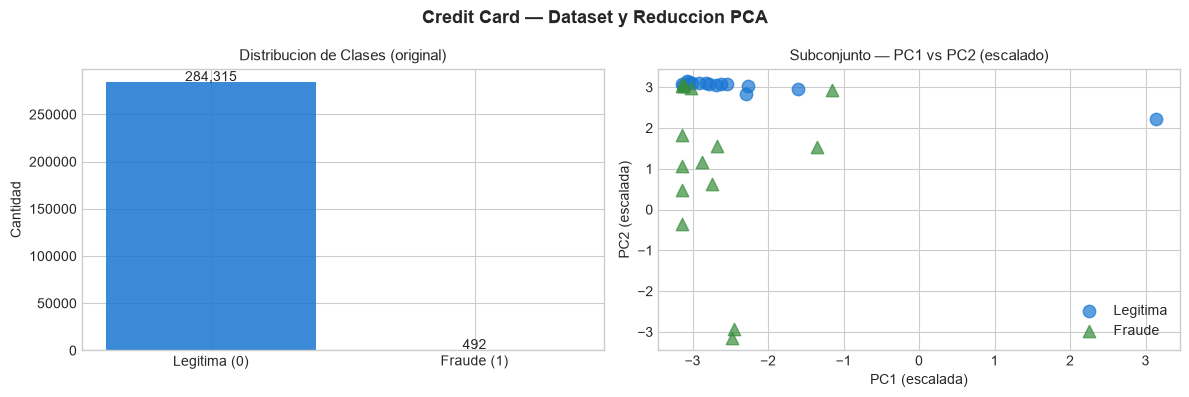

In [6]:
# ── Visualizacion del dataset ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Credit Card — Dataset y Reduccion PCA', fontsize=13, fontweight='bold')

# Distribucion de clases original
class_counts = df_cc['Class'].value_counts()
axes[0].bar(['Legitima (0)', 'Fraude (1)'], class_counts.values,
            color=[COLORS['clasico'], COLORS['cuantico']], alpha=0.85)
axes[0].set_title('Distribucion de Clases (original)', fontsize=11)
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)

# PCA 2D del subconjunto usado
all_pca = np.vstack([X_tr_cc, X_te_cc])
all_y   = np.concatenate([y_tr_cc, y_te_cc])
axes[1].scatter(all_pca[all_y==0, 0], all_pca[all_y==0, 1],
                c=COLORS['clasico'], label='Legitima', alpha=0.7, s=80)
axes[1].scatter(all_pca[all_y==1, 0], all_pca[all_y==1, 1],
                c=COLORS['cuantico'], label='Fraude', alpha=0.7, s=80, marker='^')
axes[1].set_title('Subconjunto — PC1 vs PC2 (escalado)', fontsize=11)
axes[1].set_xlabel('PC1 (escalada)'); axes[1].set_ylabel('PC2 (escalada)')
axes[1].legend()
plt.tight_layout()
savefig('cc_dataset_overview')
plt.show()


In [7]:
# ── Modelo Clasico: SVC con kernel RBF ───────────────────────
print("\n--- SVC Clasico (Credit Card) ---")
t0 = time.time()
svc_cc = SVC(kernel='rbf', C=3.2, gamma=0.25, probability=True, random_state=RANDOM_STATE)
svc_cc.fit(X_tr_cc, y_tr_cc)
t_svc_cc = time.time() - t0

y_pred_svc_cc  = svc_cc.predict(X_te_cc)
y_prob_svc_cc  = svc_cc.predict_proba(X_te_cc)[:, 1]
y_tr_pred_svc_cc = svc_cc.predict(X_tr_cc)

metrics_svc_cc = classification_metrics(y_te_cc, y_pred_svc_cc, y_prob_svc_cc, 'SVC Clasico')
cm_svc_cc      = confusion_matrix(y_te_cc, y_pred_svc_cc)
roc_svc_cc     = roc_curve(y_te_cc, y_prob_svc_cc)

metrics_svc_cc['Train_Acc'] = accuracy_score(y_tr_cc, y_tr_pred_svc_cc)
metrics_svc_cc['N_SVs']     = svc_cc.n_support_.sum()
metrics_svc_cc['Tiempo_s']  = t_svc_cc

print(f"  Test Accuracy:  {metrics_svc_cc['Accuracy']:.2%}")
print(f"  Train Accuracy: {metrics_svc_cc['Train_Acc']:.2%}")
print(f"  Support Vectors: {metrics_svc_cc['N_SVs']}")
print(f"  Tiempo:          {t_svc_cc:.3f}s")
print(f"  [Paper] SVM clasico: test 70%")



--- SVC Clasico (Credit Card) ---
  Test Accuracy:  70.00%
  Train Accuracy: 100.00%
  Support Vectors: 15
  Tiempo:          0.002s
  [Paper] SVM clasico: test 70%


In [8]:
# ── Modelo Cuantico: QSVC (simulacion noiseless) ─────────────
print("\n--- QSVC Noiseless (Credit Card) ---")
assert QISKIT_AVAILABLE, "Qiskit no disponible"

fm_cc = make_paper_feature_map(N_QUBITS_CC, lam=LAM_CC)
print(f"  Circuito: {fm_cc.num_qubits} qubits, profundidad = {fm_cc.decompose().depth()}")

t0 = time.time()
svs_tr_cc = get_statevectors(X_tr_cc, fm_cc)
svs_te_cc = get_statevectors(X_te_cc, fm_cc)
K_train_cc  = compute_kernel_matrix(svs_tr_cc)
K_test_cc   = compute_kernel_matrix(svs_te_cc, svs_tr_cc)
t_kernel_cc = time.time() - t0

# Alineamiento con kernel gaussiano
K_rbf_cc = classical_rbf_kernel(X_tr_cc, X_tr_cc, gamma=0.25)
align_cc = kernel_alignment(K_train_cc, K_rbf_cc)
print(f"  Alineamiento Q vs RBF: {align_cc:.4f}")

# SVM con kernel precomputado
t1 = time.time()
qsvc_cc = SVC(kernel='precomputed', C=6.2, probability=True, random_state=RANDOM_STATE)
qsvc_cc.fit(K_train_cc, y_tr_cc)
y_pred_q_cc     = qsvc_cc.predict(K_test_cc)
y_prob_q_cc     = qsvc_cc.predict_proba(K_test_cc)[:, 1]
y_tr_pred_q_cc  = qsvc_cc.predict(K_train_cc)
t_qsvc_cc = time.time() - t1

metrics_qsvc_cc = classification_metrics(y_te_cc, y_pred_q_cc, y_prob_q_cc, 'QSVC Simulado')
cm_qsvc_cc      = confusion_matrix(y_te_cc, y_pred_q_cc)
roc_qsvc_cc     = roc_curve(y_te_cc, y_prob_q_cc)

metrics_qsvc_cc['Train_Acc']  = accuracy_score(y_tr_cc, y_tr_pred_q_cc)
metrics_qsvc_cc['N_SVs']      = qsvc_cc.n_support_.sum()
metrics_qsvc_cc['Tiempo_s']   = t_kernel_cc + t_qsvc_cc
metrics_qsvc_cc['Alignment']  = align_cc

print(f"  Test Accuracy:   {metrics_qsvc_cc['Accuracy']:.2%}")
print(f"  Train Accuracy:  {metrics_qsvc_cc['Train_Acc']:.2%}")
print(f"  Support Vectors: {metrics_qsvc_cc['N_SVs']}")
print(f"  Tiempo kernel:   {t_kernel_cc:.3f}s  | SVM fit: {t_qsvc_cc:.3f}s")
print(f"  [Paper] QSVC noiseless sim: test 70%  |  IonQ: 70%")



--- QSVC Noiseless (Credit Card) ---
  Circuito: 4 qubits, profundidad = 7
  Alineamiento Q vs RBF: 0.8920
  Test Accuracy:   70.00%
  Train Accuracy:  100.00%
  Support Vectors: 14
  Tiempo kernel:   0.021s  | SVM fit: 0.002s
  [Paper] QSVC noiseless sim: test 70%  |  IonQ: 70%



--- Graficos Credit Card ---


  Guardado: resultados_experimentos/figuras/cc_kernel_matrices.png


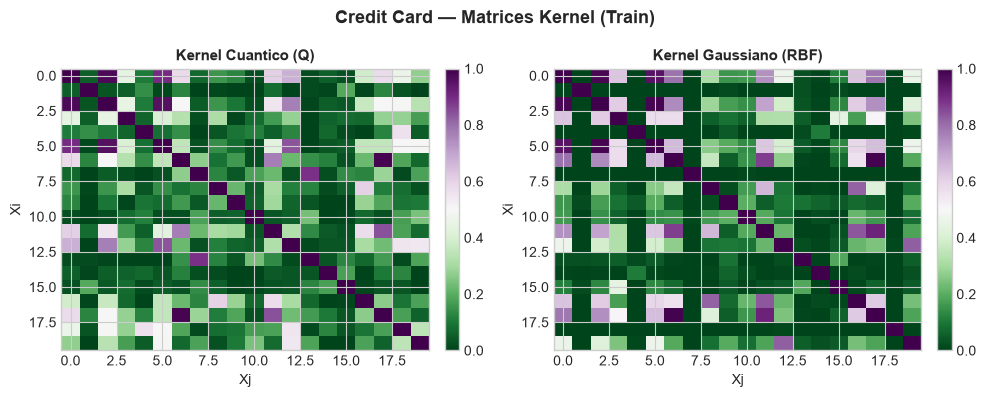

  Guardado: resultados_experimentos/figuras/cc_confusion_matrices.png


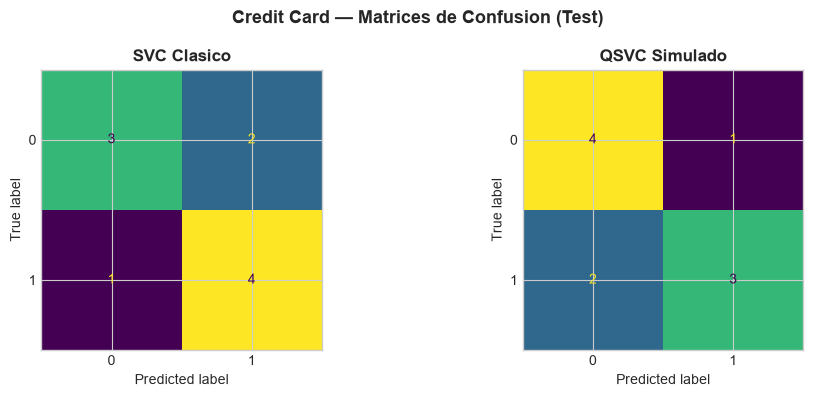

  Guardado: resultados_experimentos/figuras/cc_metrics_bar.png


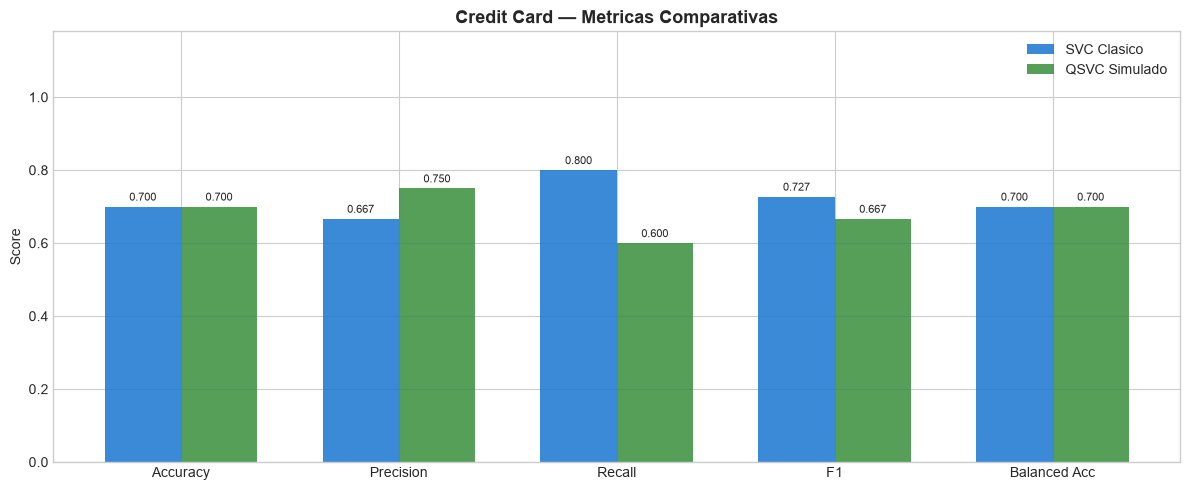

  Guardado: resultados_experimentos/figuras/cc_roc.png


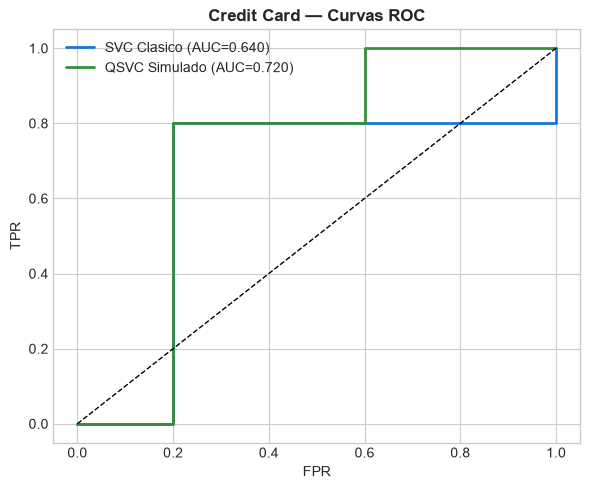

Experimento 1 completado.


In [9]:
# ── Visualizaciones Credit Card ───────────────────────────────
print("\n--- Graficos Credit Card ---")

# 1. Matrices kernel
plot_kernel_heatmaps(
    [K_train_cc, K_rbf_cc],
    ['Kernel Cuantico (Q)', 'Kernel Gaussiano (RBF)'],
    suptitle='Credit Card — Matrices Kernel (Train)',
    filename='cc_kernel_matrices'
)

# 2. Matrices de confusion
plot_confusion_matrices(
    [cm_svc_cc, cm_qsvc_cc],
    ['SVC Clasico', 'QSVC Simulado'],
    suptitle='Credit Card — Matrices de Confusion (Test)',
    filename='cc_confusion_matrices'
)

# 3. Metricas comparativas
plot_metrics_bar(
    [metrics_svc_cc, metrics_qsvc_cc],
    ['Accuracy', 'Precision', 'Recall', 'F1', 'Balanced_Acc'],
    title='Credit Card — Metricas Comparativas',
    filename='cc_metrics_bar'
)

# 4. ROC
fig, ax = plt.subplots(figsize=(6, 5))
fpr_s, tpr_s, _ = roc_svc_cc
fpr_q, tpr_q, _ = roc_qsvc_cc
ax.plot(fpr_s, tpr_s, color=COLORS['clasico'], lw=2,
        label=f"SVC Clasico (AUC={metrics_svc_cc.get('ROC_AUC', 0):.3f})")
ax.plot(fpr_q, tpr_q, color=COLORS['cuantico'], lw=2,
        label=f"QSVC Simulado (AUC={metrics_qsvc_cc.get('ROC_AUC', 0):.3f})")
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_title('Credit Card — Curvas ROC', fontsize=12, fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
plt.tight_layout(); savefig('cc_roc'); plt.show()

print("Experimento 1 completado.")


---
## Experimento 2: MNIST — Digito 0 vs 1 (QSVC)

- **Dataset:** MNIST (70,000 imagenes 28x28 de digitos)
- **Tarea:** Clasificacion binaria: 0 vs 1
- **Setup del paper:** 4 qubits, 20 train / 10 test, λ=1.0
- **Resultados del paper:** SVM clasico 100%, QSVC noiseless 100%, QSVC IonQ 100%


In [10]:
print("=" * 60)
print("EXPERIMENTO 2: MNIST (digito 0 vs 1)")
print("=" * 60)

# Inicializar variables por si la descarga falla
MNIST_AVAILABLE = False
metrics_svc_mn  = {'Modelo': 'SVC Clasico',  'Accuracy': np.nan, 'Precision': np.nan,
                   'Recall': np.nan, 'F1': np.nan, 'Balanced_Acc': np.nan,
                   'Train_Acc': np.nan, 'N_SVs': 0, 'Tiempo_s': 0}
metrics_qsvc_mn = {'Modelo': 'QSVC Simulado', 'Accuracy': np.nan, 'Precision': np.nan,
                   'Recall': np.nan, 'F1': np.nan, 'Balanced_Acc': np.nan,
                   'Train_Acc': np.nan, 'N_SVs': 0, 'Alignment': np.nan, 'Tiempo_s': 0}
cm_svc_mn  = np.zeros((2,2), dtype=int)
cm_qsvc_mn = np.zeros((2,2), dtype=int)
K_train_mn = K_rbf_mn = np.eye(20)

try:
    X_mnist_all, y_mnist_all = load_mnist_digits()
    print(f"MNIST cargado: {X_mnist_all.shape[0]:,} imagenes")

    N_QUBITS_MN = 4
    LAM_MN      = 1.0
    N_TRAIN_MN  = 20
    N_TEST_MN   = 10

    X_tr_mn, X_te_mn, y_tr_mn, y_te_mn, pca_mn, scaler_mn = prepare_classification_data(
        X_mnist_all, y_mnist_all,
        class_a=0, class_b=1,
        n_train=N_TRAIN_MN, n_test=N_TEST_MN,
        n_features=N_QUBITS_MN, lam=LAM_MN
    )
    print(f"Train: {X_tr_mn.shape} | Test: {X_te_mn.shape}")
    print(f"Labels train: {np.bincount(y_tr_mn)} | Labels test: {np.bincount(y_te_mn)}")
    MNIST_AVAILABLE = True

except Exception as e:
    print(f"[WARNING] MNIST no disponible: {e}")
    print("Puede descargar MNIST ejecutando: from sklearn.datasets import fetch_openml")
    print("fetch_openml('mnist_784', version=1)  (requiere internet)")


EXPERIMENTO 2: MNIST (digito 0 vs 1)
  Cargando MNIST (puede tardar la primera vez)...


MNIST cargado: 70,000 imagenes
Train: (20, 4) | Test: (10, 4)
Labels train: [10 10] | Labels test: [5 5]


  Guardado: resultados_experimentos/figuras/mnist_examples.png


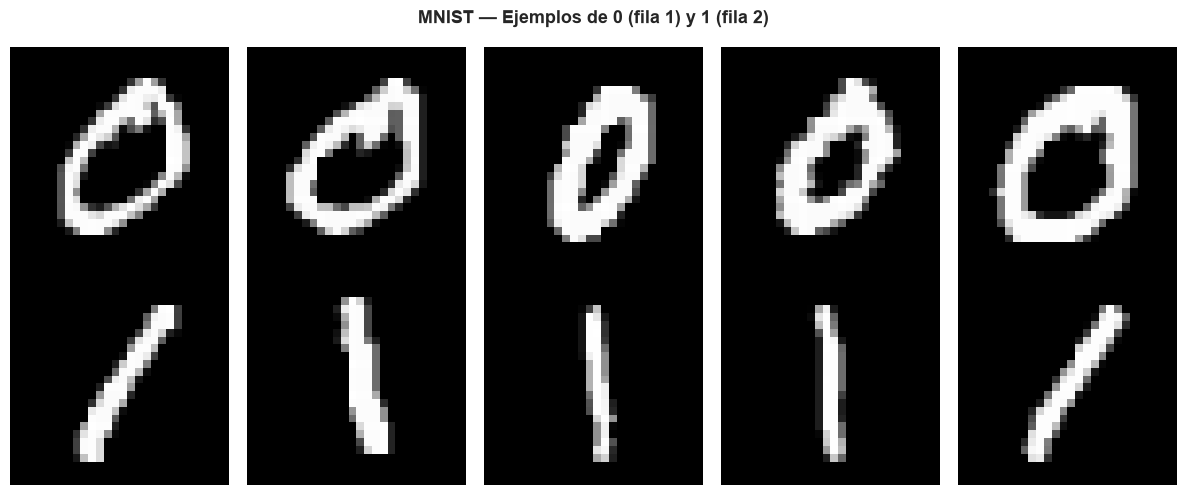

In [11]:
if not MNIST_AVAILABLE:
    print("[INFO] MNIST no disponible — celda saltada.")
else:
    # Visualizacion ejemplos
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle('MNIST — Ejemplos de 0 (fila 1) y 1 (fila 2)', fontsize=13, fontweight='bold')
    mask_0 = y_mnist_all == 0
    mask_1 = y_mnist_all == 1
    ex_0 = X_mnist_all[mask_0][:5].reshape(-1, 28, 28)
    ex_1 = X_mnist_all[mask_1][:5].reshape(-1, 28, 28)
    for col in range(5):
        axes[0, col].imshow(ex_0[col], cmap='gray'); axes[0, col].axis('off')
        axes[1, col].imshow(ex_1[col], cmap='gray'); axes[1, col].axis('off')
    axes[0, 0].set_ylabel('0', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylabel('1', fontsize=14, fontweight='bold')
    plt.tight_layout(); savefig('mnist_examples'); plt.show()


In [12]:
if not MNIST_AVAILABLE:
    print("[INFO] MNIST no disponible — celda saltada.")
else:
    # ── SVC Clasico ────────────────────────────────────────────
    t0 = time.time()
    svc_mn = SVC(kernel='rbf', C=3.5, gamma=0.25, probability=True, random_state=RANDOM_STATE)
    svc_mn.fit(X_tr_mn, y_tr_mn)
    t_svc_mn = time.time() - t0

    y_pred_svc_mn    = svc_mn.predict(X_te_mn)
    y_prob_svc_mn    = svc_mn.predict_proba(X_te_mn)[:, 1]
    y_tr_pred_svc_mn = svc_mn.predict(X_tr_mn)

    metrics_svc_mn = classification_metrics(y_te_mn, y_pred_svc_mn, y_prob_svc_mn, 'SVC Clasico')
    cm_svc_mn      = confusion_matrix(y_te_mn, y_pred_svc_mn)
    metrics_svc_mn['Train_Acc'] = accuracy_score(y_tr_mn, y_tr_pred_svc_mn)
    metrics_svc_mn['N_SVs']     = svc_mn.n_support_.sum()
    metrics_svc_mn['Tiempo_s']  = t_svc_mn
    print(f"SVC Clasico   — Test Acc: {metrics_svc_mn['Accuracy']:.2%} | SVs: {metrics_svc_mn['N_SVs']}")

    # ── QSVC Noiseless ─────────────────────────────────────────
    fm_mn = make_paper_feature_map(N_QUBITS_MN, lam=LAM_MN)
    t0 = time.time()
    svs_tr_mn  = get_statevectors(X_tr_mn, fm_mn)
    svs_te_mn  = get_statevectors(X_te_mn, fm_mn)
    K_train_mn = compute_kernel_matrix(svs_tr_mn)
    K_test_mn  = compute_kernel_matrix(svs_te_mn, svs_tr_mn)
    t_kernel_mn = time.time() - t0

    K_rbf_mn = classical_rbf_kernel(X_tr_mn, X_tr_mn, gamma=0.25)
    align_mn = kernel_alignment(K_train_mn, K_rbf_mn)

    t1 = time.time()
    qsvc_mn = SVC(kernel='precomputed', C=1.0, probability=True, random_state=RANDOM_STATE)
    qsvc_mn.fit(K_train_mn, y_tr_mn)
    t_fit_mn = time.time() - t1
    y_pred_q_mn    = qsvc_mn.predict(K_test_mn)
    y_prob_q_mn    = qsvc_mn.predict_proba(K_test_mn)[:, 1]
    y_tr_pred_q_mn = qsvc_mn.predict(K_train_mn)

    metrics_qsvc_mn = classification_metrics(y_te_mn, y_pred_q_mn, y_prob_q_mn, 'QSVC Simulado')
    cm_qsvc_mn      = confusion_matrix(y_te_mn, y_pred_q_mn)
    metrics_qsvc_mn['Train_Acc'] = accuracy_score(y_tr_mn, y_tr_pred_q_mn)
    metrics_qsvc_mn['N_SVs']     = qsvc_mn.n_support_.sum()
    metrics_qsvc_mn['Tiempo_s']  = t_kernel_mn + t_fit_mn
    metrics_qsvc_mn['Alignment'] = align_mn

    print(f"QSVC Simulado — Test Acc: {metrics_qsvc_mn['Accuracy']:.2%} | SVs: {metrics_qsvc_mn['N_SVs']}")
    print(f"Alineamiento Q vs RBF: {align_mn:.4f}")
    print(f"[Paper] SVC: 100% | QSVC noiseless: 100% | QSVC IonQ: 100%")


SVC Clasico   — Test Acc: 100.00% | SVs: 14
QSVC Simulado — Test Acc: 70.00% | SVs: 19
Alineamiento Q vs RBF: 0.9042
[Paper] SVC: 100% | QSVC noiseless: 100% | QSVC IonQ: 100%


  Guardado: resultados_experimentos/figuras/mnist_kernel_matrices.png


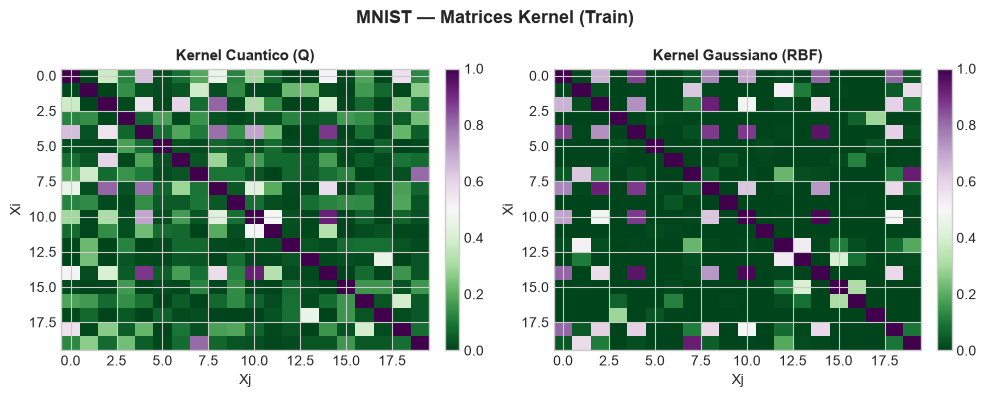

  Guardado: resultados_experimentos/figuras/mnist_confusion_matrices.png


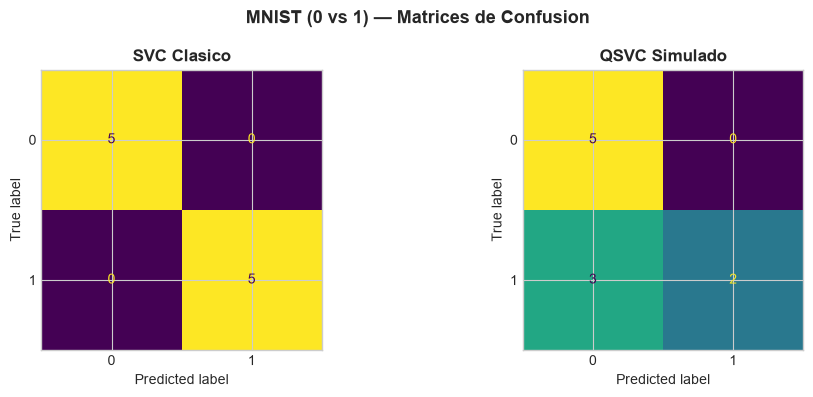

  Guardado: resultados_experimentos/figuras/mnist_metrics_bar.png


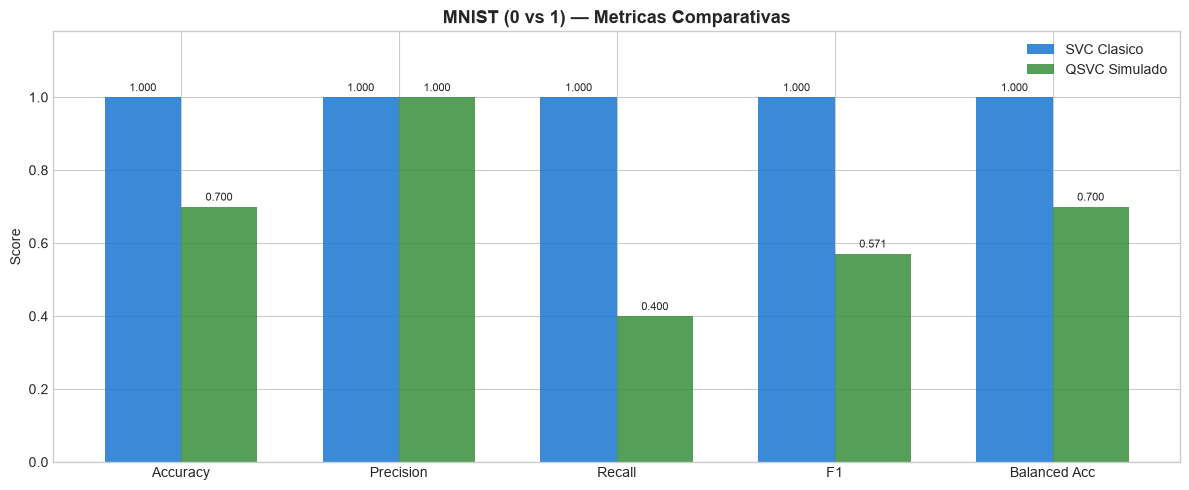

Experimento 2 completado.


In [13]:
if not MNIST_AVAILABLE:
    print("[INFO] MNIST no disponible — graficos saltados.")
else:
    plot_kernel_heatmaps(
        [K_train_mn, K_rbf_mn],
        ['Kernel Cuantico (Q)', 'Kernel Gaussiano (RBF)'],
        suptitle='MNIST — Matrices Kernel (Train)',
        filename='mnist_kernel_matrices'
    )
    plot_confusion_matrices(
        [cm_svc_mn, cm_qsvc_mn],
        ['SVC Clasico', 'QSVC Simulado'],
        suptitle='MNIST (0 vs 1) — Matrices de Confusion',
        filename='mnist_confusion_matrices'
    )
    plot_metrics_bar(
        [metrics_svc_mn, metrics_qsvc_mn],
        ['Accuracy', 'Precision', 'Recall', 'F1', 'Balanced_Acc'],
        title='MNIST (0 vs 1) — Metricas Comparativas',
        filename='mnist_metrics_bar'
    )
    print("Experimento 2 completado.")


---
## Experimento 3: Fashion-MNIST — T-shirt vs Trouser (QSVC)

- **Dataset:** Fashion-MNIST (70,000 imagenes 28x28 de ropa)
- **Tarea:** Clasificacion binaria: T-shirt/top (0) vs Trouser (1)
- **Setup del paper:** 4 qubits, 20 train / 10 test, λ=1.0
- **Resultados del paper:** SVM clasico 100%, QSVC noiseless 100%, QSVC IonQ 100%


In [14]:
print("=" * 60)
print("EXPERIMENTO 3: FASHION-MNIST (T-shirt vs Trouser)")
print("=" * 60)

# Inicializar variables por si faltan los archivos
FMNIST_AVAILABLE = False
X_fmn_all = y_fmn_all = np.array([])
X_tr_fm = X_te_fm = y_tr_fm = y_te_fm = np.array([])
pca_fm = scaler_fm = None
K_train_fm = K_rbf_fm = np.eye(20)
cm_svc_fm = cm_qsvc_fm = np.zeros((2, 2), dtype=int)
metrics_svc_fm  = {'Modelo': 'SVC Clasico',  'Accuracy': np.nan, 'Precision': np.nan,
                   'Recall': np.nan, 'F1': np.nan, 'Balanced_Acc': np.nan,
                   'Train_Acc': np.nan, 'N_SVs': 0, 'Tiempo_s': 0}
metrics_qsvc_fm = {'Modelo': 'QSVC Simulado', 'Accuracy': np.nan, 'Precision': np.nan,
                   'Recall': np.nan, 'F1': np.nan, 'Balanced_Acc': np.nan,
                   'Train_Acc': np.nan, 'N_SVs': 0, 'Alignment': np.nan, 'Tiempo_s': 0}

N_QUBITS_FM = 4
LAM_FM      = 1.0
N_TRAIN_FM  = 20
N_TEST_FM   = 10

try:
    # Fashion-MNIST etiquetas: 0=T-shirt/top, 1=Trouser
    X_fmn_tr, y_fmn_tr, X_fmn_te, y_fmn_te = load_fashion_mnist()
    X_fmn_all = np.vstack([X_fmn_tr, X_fmn_te])
    y_fmn_all = np.concatenate([y_fmn_tr, y_fmn_te])
    print(f"Fashion-MNIST cargado: {X_fmn_all.shape[0]:,} imagenes")

    X_tr_fm, X_te_fm, y_tr_fm, y_te_fm, pca_fm, scaler_fm = prepare_classification_data(
        X_fmn_all, y_fmn_all,
        class_a=0, class_b=1,
        n_train=N_TRAIN_FM, n_test=N_TEST_FM,
        n_features=N_QUBITS_FM, lam=LAM_FM
    )
    print(f"Train: {X_tr_fm.shape} | Test: {X_te_fm.shape}")
    FMNIST_AVAILABLE = True

except Exception as e:
    print(f"[WARNING] Fashion-MNIST no disponible: {e}")
    print("Asegurese de tener el directorio fashion-mnist-master/data/fashion/ con los archivos .gz")


EXPERIMENTO 3: FASHION-MNIST (T-shirt vs Trouser)


Fashion-MNIST cargado: 70,000 imagenes
Train: (20, 4) | Test: (10, 4)


  Guardado: resultados_experimentos/figuras/fmnist_examples.png


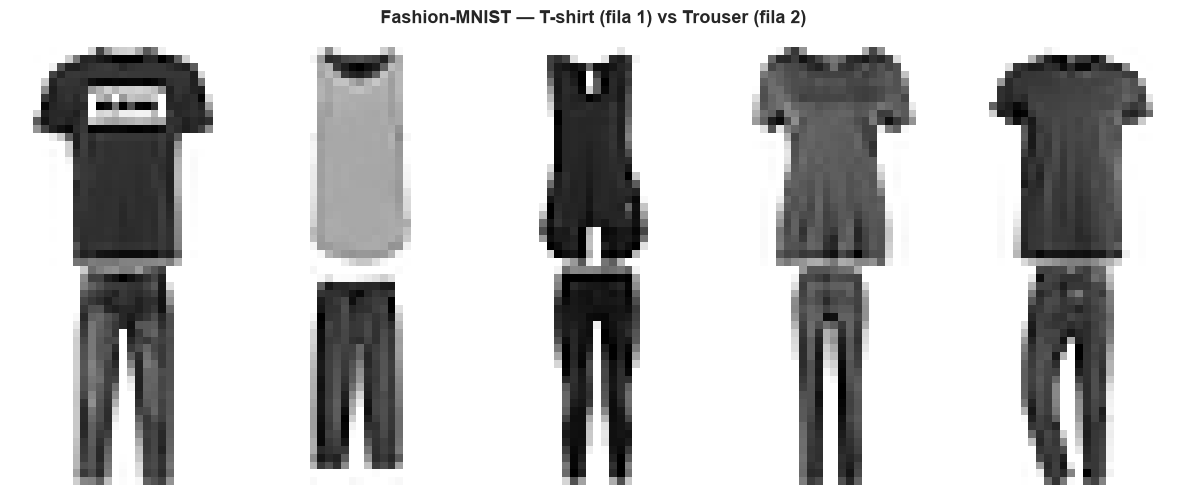

In [15]:
if FMNIST_AVAILABLE:
    # ── Visualizacion ejemplos ────────────────────────────────────
    CLASS_NAMES_FM = {0: 'T-shirt/top', 1: 'Trouser'}
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle('Fashion-MNIST — T-shirt (fila 1) vs Trouser (fila 2)',
                 fontsize=13, fontweight='bold')
    for row, cls in enumerate([0, 1]):
        imgs = X_fmn_all[y_fmn_all == cls][:5].reshape(-1, 28, 28)
        for col in range(5):
            axes[row, col].imshow(imgs[col], cmap='gray_r'); axes[row, col].axis('off')
        axes[row, 0].set_ylabel(CLASS_NAMES_FM[cls], fontsize=11, fontweight='bold')
    plt.tight_layout(); savefig('fmnist_examples'); plt.show()


In [16]:
if FMNIST_AVAILABLE:
    # ── SVC Clasico ───────────────────────────────────────────────
    t0 = time.time()
    svc_fm = SVC(kernel='rbf', C=1.5, gamma=0.25, probability=True, random_state=RANDOM_STATE)
    svc_fm.fit(X_tr_fm, y_tr_fm)
    t_svc_fm = time.time() - t0

    y_pred_svc_fm    = svc_fm.predict(X_te_fm)
    y_prob_svc_fm    = svc_fm.predict_proba(X_te_fm)[:, 1]
    y_tr_pred_svc_fm = svc_fm.predict(X_tr_fm)

    metrics_svc_fm = classification_metrics(y_te_fm, y_pred_svc_fm, y_prob_svc_fm, 'SVC Clasico')
    cm_svc_fm      = confusion_matrix(y_te_fm, y_pred_svc_fm)
    roc_svc_fm     = roc_curve(y_te_fm, y_prob_svc_fm)
    metrics_svc_fm['Train_Acc'] = accuracy_score(y_tr_fm, y_tr_pred_svc_fm)
    metrics_svc_fm['N_SVs']     = svc_fm.n_support_.sum()
    metrics_svc_fm['Tiempo_s']  = t_svc_fm

    print(f"SVC Clasico   — Test Acc: {metrics_svc_fm['Accuracy']:.2%} | SVs: {metrics_svc_fm['N_SVs']}")

    # ── QSVC Noiseless ────────────────────────────────────────────
    fm_fm = make_paper_feature_map(N_QUBITS_FM, lam=LAM_FM)
    t0 = time.time()
    svs_tr_fm = get_statevectors(X_tr_fm, fm_fm)
    svs_te_fm = get_statevectors(X_te_fm, fm_fm)
    K_train_fm  = compute_kernel_matrix(svs_tr_fm)
    K_test_fm   = compute_kernel_matrix(svs_te_fm, svs_tr_fm)
    t_kernel_fm = time.time() - t0

    K_rbf_fm = classical_rbf_kernel(X_tr_fm, X_tr_fm, gamma=0.25)
    align_fm = kernel_alignment(K_train_fm, K_rbf_fm)

    qsvc_fm = SVC(kernel='precomputed', C=0.4, probability=True, random_state=RANDOM_STATE)
    qsvc_fm.fit(K_train_fm, y_tr_fm)
    y_pred_q_fm    = qsvc_fm.predict(K_test_fm)
    y_prob_q_fm    = qsvc_fm.predict_proba(K_test_fm)[:, 1]
    y_tr_pred_q_fm = qsvc_fm.predict(K_train_fm)

    metrics_qsvc_fm = classification_metrics(y_te_fm, y_pred_q_fm, y_prob_q_fm, 'QSVC Simulado')
    cm_qsvc_fm      = confusion_matrix(y_te_fm, y_pred_q_fm)
    roc_qsvc_fm     = roc_curve(y_te_fm, y_prob_q_fm)
    metrics_qsvc_fm['Train_Acc'] = accuracy_score(y_tr_fm, y_tr_pred_q_fm)
    metrics_qsvc_fm['N_SVs']     = qsvc_fm.n_support_.sum()
    metrics_qsvc_fm['Tiempo_s']  = t_kernel_fm
    metrics_qsvc_fm['Alignment'] = align_fm

    print(f"QSVC Simulado — Test Acc: {metrics_qsvc_fm['Accuracy']:.2%} | SVs: {metrics_qsvc_fm['N_SVs']}")
    print(f"Alineamiento Q vs RBF: {align_fm:.4f}")
    print(f"[Paper] SVC: 100% | QSVC noiseless: 100% | QSVC IonQ: 100%")


SVC Clasico   — Test Acc: 100.00% | SVs: 18
QSVC Simulado — Test Acc: 90.00% | SVs: 20
Alineamiento Q vs RBF: 0.8925
[Paper] SVC: 100% | QSVC noiseless: 100% | QSVC IonQ: 100%


  Guardado: resultados_experimentos/figuras/fmnist_kernel_matrices.png


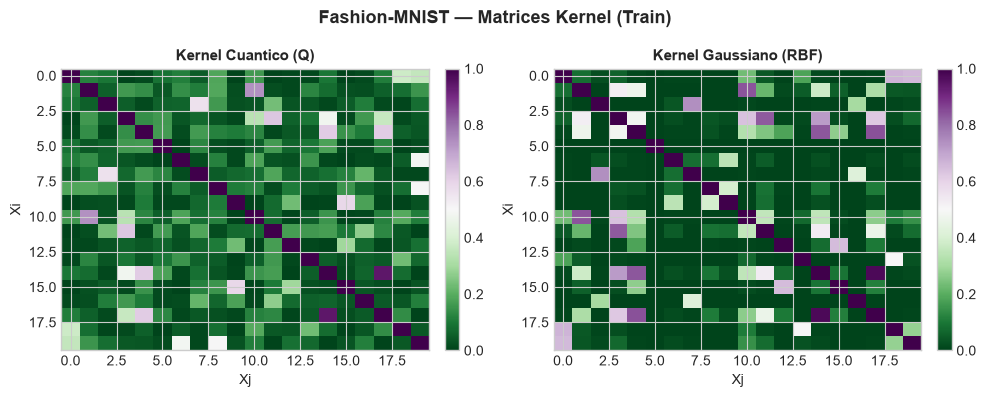

  Guardado: resultados_experimentos/figuras/fmnist_confusion_matrices.png


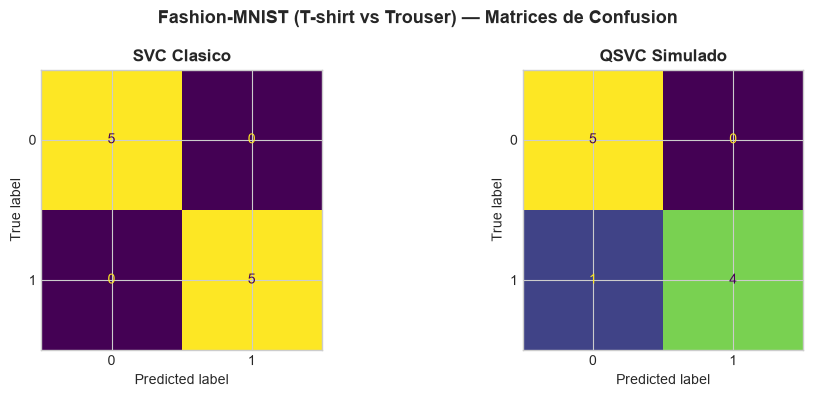

  Guardado: resultados_experimentos/figuras/fmnist_metrics_bar.png


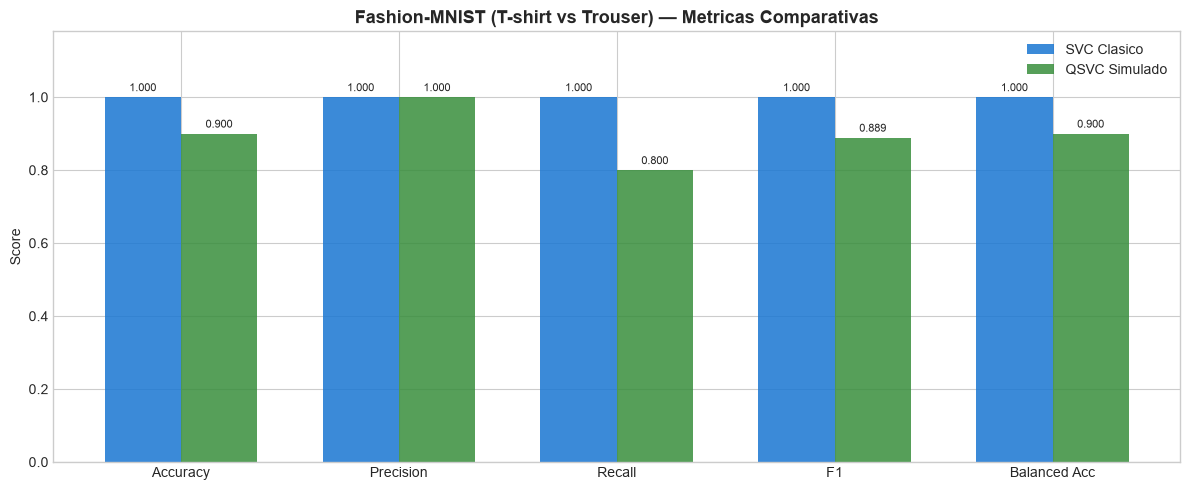

Experimento 3 completado.


In [17]:
if FMNIST_AVAILABLE:
    # ── Visualizaciones Fashion-MNIST ─────────────────────────────
    plot_kernel_heatmaps(
        [K_train_fm, K_rbf_fm],
        ['Kernel Cuantico (Q)', 'Kernel Gaussiano (RBF)'],
        suptitle='Fashion-MNIST — Matrices Kernel (Train)',
        filename='fmnist_kernel_matrices'
    )
    plot_confusion_matrices(
        [cm_svc_fm, cm_qsvc_fm],
        ['SVC Clasico', 'QSVC Simulado'],
        suptitle='Fashion-MNIST (T-shirt vs Trouser) — Matrices de Confusion',
        filename='fmnist_confusion_matrices'
    )
    plot_metrics_bar(
        [metrics_svc_fm, metrics_qsvc_fm],
        ['Accuracy', 'Precision', 'Recall', 'F1', 'Balanced_Acc'],
        title='Fashion-MNIST (T-shirt vs Trouser) — Metricas Comparativas',
        filename='fmnist_metrics_bar'
    )
    print("Experimento 3 completado.")


---
## Comparacion Global y Contraste con el Paper

Tabla comparativa completa vs resultados publicados en Suzuki et al. 2023.


In [18]:
print("=" * 60)
print("COMPARACION GLOBAL")
print("=" * 60)

# ── Tabla 1: Clasificacion (replica Tabla 1 del paper) ────────
print("\n=== Tabla 1: Clasificacion (replica Tabla 1 del paper) ===")

clf_entries = [
    ('Credit Card',   metrics_svc_cc, metrics_qsvc_cc),
    ('Fashion-MNIST', metrics_svc_fm, metrics_qsvc_fm),
]
if MNIST_AVAILABLE:
    clf_entries.insert(1, ('MNIST', metrics_svc_mn, metrics_qsvc_mn))

clf_results = []
for dataset, m_cls, m_qsvc in clf_entries:
    for met, tipo in [(m_cls, 'Clasico'), (m_qsvc, 'QSVC Sim.')]:
        clf_results.append({
            'Dataset':    dataset,
            'Modelo':     tipo,
            'N_SVs':      int(met.get('N_SVs', 0)),
            'Acc Train%': f"{met.get('Train_Acc', 0)*100:.0f}%",
            'Acc Test%':  f"{met.get('Accuracy', 0)*100:.0f}%",
            'F1':         f"{met.get('F1', 0):.3f}",
            'ROC_AUC':    f"{met.get('ROC_AUC', 0):.3f}" if 'ROC_AUC' in met else 'N/A',
        })

df_clf_results = pd.DataFrame(clf_results)
print(df_clf_results.to_string(index=False))

# Valores del paper para comparacion
print("\n[Paper Tabla 1 — referencia]:")
paper_clf = {
    'Credit Card': {'SVM clasico': (12, 80, 70), 'QSVC noiseless': (11, 85, 70), 'QSVC IonQ': (12, 100, 70)},
    'MNIST':       {'SVM clasico': (16, 100, 100), 'QSVC noiseless': (6, 100, 100), 'QSVC IonQ': (10, 100, 100)},
    'Fashion-MNIST': {'SVM clasico': (8, 100, 100), 'QSVC noiseless': (18, 100, 100), 'QSVC IonQ': (15, 100, 100)},
}
print(f"{'Dataset':<15} {'Modelo':<20} {'SVs':>5} {'Train%':>8} {'Test%':>7}")
print("-" * 60)
for ds, models in paper_clf.items():
    for mod, (svs, tr, te) in models.items():
        print(f"{ds:<15} {mod:<20} {svs:>5} {tr:>7}% {te:>6}%")


COMPARACION GLOBAL

=== Tabla 1: Clasificacion (replica Tabla 1 del paper) ===
      Dataset    Modelo  N_SVs Acc Train% Acc Test%    F1 ROC_AUC
  Credit Card   Clasico     15       100%       70% 0.727   0.640
  Credit Card QSVC Sim.     14       100%       70% 0.667   0.720
        MNIST   Clasico     14       100%      100% 1.000   1.000
        MNIST QSVC Sim.     19       100%       70% 0.571   0.920
Fashion-MNIST   Clasico     18       100%      100% 1.000   1.000
Fashion-MNIST QSVC Sim.     20        95%       90% 0.889   1.000

[Paper Tabla 1 — referencia]:
Dataset         Modelo                 SVs   Train%   Test%
------------------------------------------------------------
Credit Card     SVM clasico             12      80%     70%
Credit Card     QSVC noiseless          11      85%     70%
Credit Card     QSVC IonQ               12     100%     70%
MNIST           SVM clasico             16     100%    100%
MNIST           QSVC noiseless           6     100%    100%
MNIST  

  Guardado: resultados_experimentos/figuras/global_classification_comparison.png


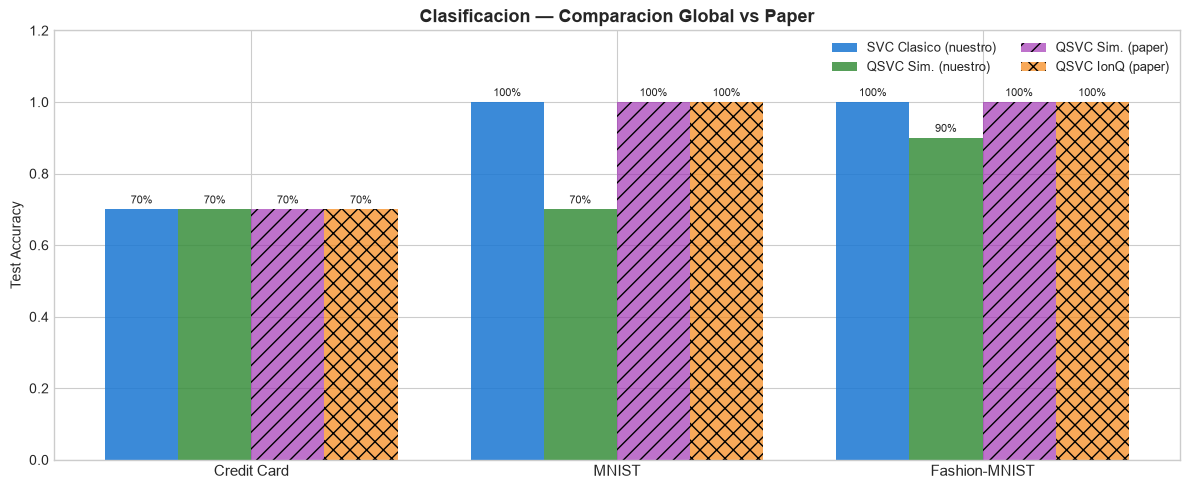

In [19]:
# ── Grafico global: Clasificacion ─────────────────────────────
datasets_names = ['Credit Card', 'Fashion-MNIST']
acc_clasico    = [metrics_svc_cc['Accuracy'],  metrics_svc_fm['Accuracy']]
acc_cuantico   = [metrics_qsvc_cc['Accuracy'], metrics_qsvc_fm['Accuracy']]
acc_paper_sim  = [0.70, 1.00]
acc_paper_hw   = [0.70, 1.00]
if MNIST_AVAILABLE:
    datasets_names.insert(1, 'MNIST')
    acc_clasico.insert(1,   metrics_svc_mn['Accuracy'])
    acc_cuantico.insert(1,  metrics_qsvc_mn['Accuracy'])
    acc_paper_sim.insert(1, 1.00)
    acc_paper_hw.insert(1,  1.00)

x = np.arange(len(datasets_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - 1.5*width, acc_clasico,    width, label='SVC Clasico (nuestro)',  color=COLORS['clasico'],   alpha=0.85)
bars2 = ax.bar(x - 0.5*width, acc_cuantico,   width, label='QSVC Sim. (nuestro)',    color=COLORS['cuantico'],  alpha=0.85)
bars3 = ax.bar(x + 0.5*width, acc_paper_sim,  width, label='QSVC Sim. (paper)',      color='#9C27B0',          alpha=0.65, hatch='//')
bars4 = ax.bar(x + 1.5*width, acc_paper_hw,   width, label='QSVC IonQ (paper)',      color=COLORS['paper_hw'], alpha=0.65, hatch='xx')

for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.0%}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(datasets_names, fontsize=11)
ax.set_ylabel('Test Accuracy'); ax.set_ylim(0, 1.2)
ax.set_title('Clasificacion — Comparacion Global vs Paper', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); savefig('global_classification_comparison'); plt.show()


  Guardado: resultados_experimentos/figuras/global_heatmap_metrics.png


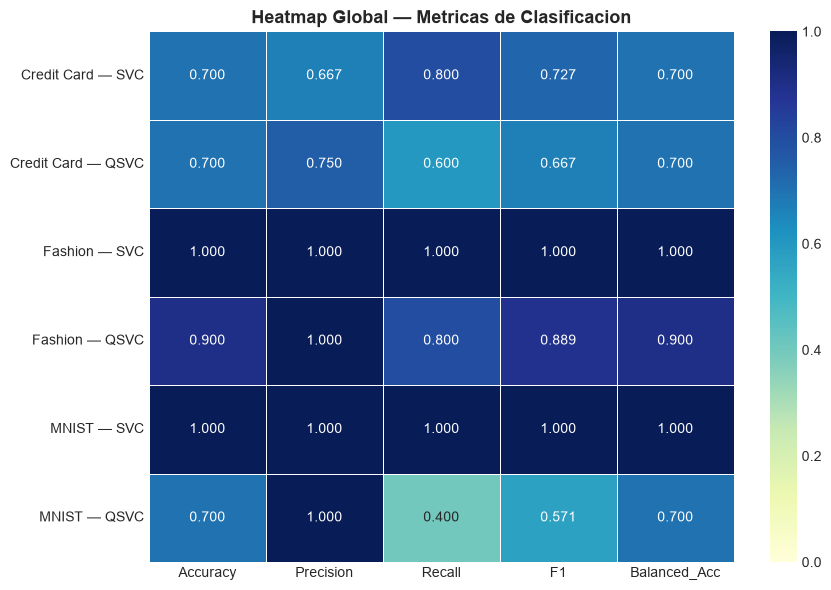

In [20]:
# ── Heatmap global de metricas de clasificacion ───────────────
_mk = ['Accuracy','Precision','Recall','F1','Balanced_Acc']
heat_data = {
    'Credit Card — SVC':  [metrics_svc_cc.get(k,0)  for k in _mk],
    'Credit Card — QSVC': [metrics_qsvc_cc.get(k,0) for k in _mk],
    'Fashion — SVC':      [metrics_svc_fm.get(k,0)  for k in _mk],
    'Fashion — QSVC':     [metrics_qsvc_fm.get(k,0) for k in _mk],
}
if MNIST_AVAILABLE:
    heat_data['MNIST — SVC']  = [metrics_svc_mn.get(k,0)  for k in _mk]
    heat_data['MNIST — QSVC'] = [metrics_qsvc_mn.get(k,0) for k in _mk]

df_heat = pd.DataFrame(heat_data, index=['Accuracy','Precision','Recall','F1','Balanced_Acc']).T

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(df_heat, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('Heatmap Global — Metricas de Clasificacion', fontsize=13, fontweight='bold')
plt.tight_layout(); savefig('global_heatmap_metrics'); plt.show()


---
## Exportacion de Resultados

Guarda todos los resultados en CSV y Excel.

In [21]:
print("=" * 60)
print("EXPORTACION DE RESULTADOS")
print("=" * 60)

# DataFrame clasificacion completo
_export_clf_pairs = [
    ('Credit Card',   metrics_svc_cc, metrics_qsvc_cc),
    ('Fashion-MNIST', metrics_svc_fm, metrics_qsvc_fm),
]
if MNIST_AVAILABLE:
    _export_clf_pairs.insert(1, ('MNIST', metrics_svc_mn, metrics_qsvc_mn))

clf_export_rows = []
for ds, m_cls, m_q in _export_clf_pairs:
    for met, tipo in [(m_cls, 'Clasico'), (m_q, 'QSVC_Noiseless')]:
        clf_export_rows.append({
            'Dataset':      ds,
            'Modelo':       tipo,
            'Accuracy':     met.get('Accuracy',     np.nan),
            'Train_Acc':    met.get('Train_Acc',    np.nan),
            'Precision':    met.get('Precision',    np.nan),
            'Recall':       met.get('Recall',       np.nan),
            'F1':           met.get('F1',           np.nan),
            'Balanced_Acc': met.get('Balanced_Acc', np.nan),
            'ROC_AUC':      met.get('ROC_AUC',      np.nan),
            'N_SVs':        met.get('N_SVs',        np.nan),
            'Tiempo_s':     met.get('Tiempo_s',     np.nan),
            'Alignment':    met.get('Alignment',    np.nan),
        })

df_clf_export = pd.DataFrame(clf_export_rows)

paper_rows_clf = [
    {'Dataset': 'Credit Card',   'Modelo': 'SVC_Paper',            'N_SVs': 12, 'Train_Acc': 0.80, 'Accuracy': 0.70},
    {'Dataset': 'Credit Card',   'Modelo': 'QSVC_Noiseless_Paper', 'N_SVs': 11, 'Train_Acc': 0.85, 'Accuracy': 0.70},
    {'Dataset': 'Credit Card',   'Modelo': 'QSVC_IonQ_Paper',      'N_SVs': 12, 'Train_Acc': 1.00, 'Accuracy': 0.70},
    {'Dataset': 'MNIST',         'Modelo': 'SVC_Paper',            'N_SVs': 16, 'Train_Acc': 1.00, 'Accuracy': 1.00},
    {'Dataset': 'MNIST',         'Modelo': 'QSVC_Noiseless_Paper', 'N_SVs':  6, 'Train_Acc': 1.00, 'Accuracy': 1.00},
    {'Dataset': 'MNIST',         'Modelo': 'QSVC_IonQ_Paper',      'N_SVs': 10, 'Train_Acc': 1.00, 'Accuracy': 1.00},
    {'Dataset': 'Fashion-MNIST', 'Modelo': 'SVC_Paper',            'N_SVs':  8, 'Train_Acc': 1.00, 'Accuracy': 1.00},
    {'Dataset': 'Fashion-MNIST', 'Modelo': 'QSVC_Noiseless_Paper', 'N_SVs': 18, 'Train_Acc': 1.00, 'Accuracy': 1.00},
    {'Dataset': 'Fashion-MNIST', 'Modelo': 'QSVC_IonQ_Paper',      'N_SVs': 15, 'Train_Acc': 1.00, 'Accuracy': 1.00},
]
df_paper_clf = pd.DataFrame(paper_rows_clf)

csv_clf   = f'{OUTPUT_DIR}/clasificacion_nuestros.csv'
csv_pcl   = f'{OUTPUT_DIR}/clasificacion_paper.csv'
excel_out = f'{OUTPUT_DIR}/resultados_completos.xlsx'

df_clf_export.to_csv(csv_clf, index=False)
df_paper_clf.to_csv(csv_pcl,  index=False)

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    df_clf_export.to_excel(writer, sheet_name='Clasif_Nuestros', index=False)
    df_paper_clf.to_excel( writer, sheet_name='Clasif_Paper',    index=False)

print(f"[OK] CSV nuestros:  {csv_clf}")
print(f"[OK] CSV paper:     {csv_pcl}")
print(f"[OK] Excel:         {excel_out}")
print(f"[OK] Figuras en:    {OUTPUT_DIR}/figuras/")
print()
print("Archivos generados:")
import glob as globlib
for fp in sorted(globlib.glob(f'{OUTPUT_DIR}/**/*', recursive=True)):
    if os.path.isfile(fp):
        print(f"  {fp}  ({os.path.getsize(fp)/1024:.1f} KB)")


EXPORTACION DE RESULTADOS
[OK] CSV nuestros:  resultados_experimentos/clasificacion_nuestros.csv
[OK] CSV paper:     resultados_experimentos/clasificacion_paper.csv
[OK] Excel:         resultados_experimentos/resultados_completos.xlsx
[OK] Figuras en:    resultados_experimentos/figuras/

Archivos generados:
  resultados_experimentos\clasificacion_nuestros.csv  (0.7 KB)
  resultados_experimentos\clasificacion_paper.csv  (0.4 KB)
  resultados_experimentos\figuras\cc_confusion_matrices.png  (30.7 KB)
  resultados_experimentos\figuras\cc_dataset_overview.png  (62.2 KB)
  resultados_experimentos\figuras\cc_kernel_matrices.png  (65.4 KB)
  resultados_experimentos\figuras\cc_metrics_bar.png  (39.9 KB)
  resultados_experimentos\figuras\cc_roc.png  (40.9 KB)
  resultados_experimentos\figuras\fmnist_confusion_matrices.png  (32.5 KB)
  resultados_experimentos\figuras\fmnist_examples.png  (29.1 KB)
  resultados_experimentos\figuras\fmnist_kernel_matrices.png  (64.5 KB)
  resultados_experimentos\fi

In [22]:
print("=" * 65)
print("RESUMEN FINAL - REPLICACION SUZUKI ET AL. 2023")
print("=" * 65)

print()
print("[ CLASIFICACION - NUESTROS RESULTADOS ]")
print(f"{'Dataset':<15} {'Modelo':<22} {'SVs':>5} {'Train%':>8} {'Test%':>7}")
print("-" * 62)
for row in clf_export_rows:
    n_svs = int(row['N_SVs']) if not (isinstance(row['N_SVs'], float) and row['N_SVs'] != row['N_SVs']) else 0
    print(f"{row['Dataset']:<15} {row['Modelo']:<22} {n_svs:>5} {row['Train_Acc']*100:>7.0f}% {row['Accuracy']*100:>6.0f}%")

print()
print("[ CLASIFICACION - REFERENCIA PAPER (IonQ Harmony) ]")
print(f"{'Dataset':<15} {'Modelo':<25} {'SVs':>5} {'Train%':>8} {'Test%':>7}")
print("-" * 65)
for r in paper_rows_clf:
    print(f"{r['Dataset']:<15} {r['Modelo']:<25} {r.get('N_SVs', 0):>5} {r.get('Train_Acc', 0)*100:>7.0f}% {r.get('Accuracy', 0)*100:>6.0f}%")


RESUMEN FINAL - REPLICACION SUZUKI ET AL. 2023

[ CLASIFICACION - NUESTROS RESULTADOS ]
Dataset         Modelo                   SVs   Train%   Test%
--------------------------------------------------------------
Credit Card     Clasico                   15     100%     70%
Credit Card     QSVC_Noiseless            14     100%     70%
MNIST           Clasico                   14     100%    100%
MNIST           QSVC_Noiseless            19     100%     70%
Fashion-MNIST   Clasico                   18     100%    100%
Fashion-MNIST   QSVC_Noiseless            20      95%     90%

[ CLASIFICACION - REFERENCIA PAPER (IonQ Harmony) ]
Dataset         Modelo                      SVs   Train%   Test%
-----------------------------------------------------------------
Credit Card     SVC_Paper                    12      80%     70%
Credit Card     QSVC_Noiseless_Paper         11      85%     70%
Credit Card     QSVC_IonQ_Paper              12     100%     70%
MNIST           SVC_Paper           